# Segmentación y Clasificación de Imágenes
**Autores:** Lucia Fuentes González (210229) , Tania Mobasser Aslfakouri (220299) y Miriam Bernat Jimenez (210162) 

- **Escenario 1:** Suelo + línea (azul) + marca/flecha (rojo)
- **Escenario 2:** Objeto circular sobre fondo homogéneo + cálculo de distancia

In [1]:
import numpy as np
import cv2
import imageio.v3 as iio
from matplotlib import pyplot as plt
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score
import os
%matplotlib inline

---
## 1. Datos de entrenamiento

Cargamos las imágenes etiquetadas de la práctica anterior (imagen original + imagen marcada).
Extraemos los valores de color de cada región para formar el conjunto de entrenamiento.

In [2]:
# Funcion de normalizacion rg (de la practica anterior)
def normaliza_rg(im):
    im_float = im.astype(np.float64)
    suma = im_float.sum(axis=2, keepdims=True)
    suma[suma == 0] = 1.0
    return im_float / suma

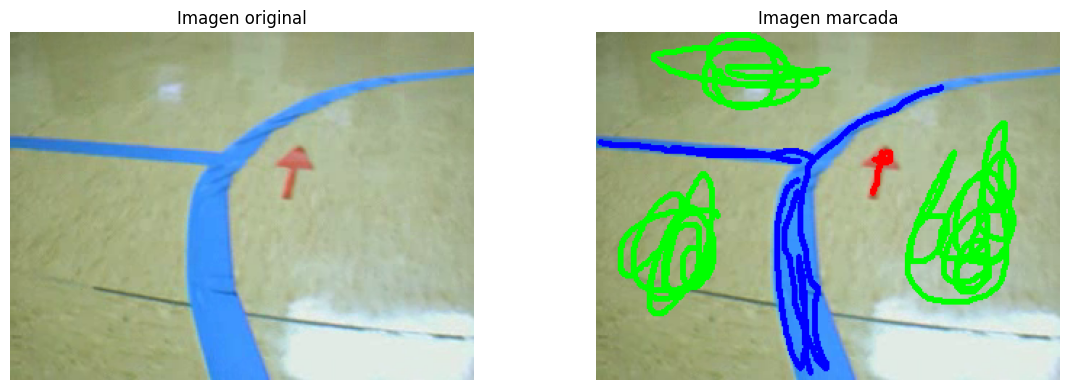

In [6]:
# Leo las imagenes de entrenamiento
imNp = iio.imread('../images/001.png')
markImg = iio.imread('../images/001_mark.png')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(imNp)
plt.title('Imagen original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(markImg)
plt.title('Imagen marcada')
plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Mascaras booleanas para cada color puro
mk = markImg[:, :, :3]
mask_marca = (mk[:,:,0] == 255) & (mk[:,:,1] == 0) & (mk[:,:,2] == 0)   # rojo = marca
mask_fondo = (mk[:,:,0] == 0) & (mk[:,:,1] == 255) & (mk[:,:,2] == 0)   # verde = fondo/suelo
mask_linea = (mk[:,:,0] == 0) & (mk[:,:,1] == 0) & (mk[:,:,2] == 255)   # azul = linea

print('Pixeles marca:', mask_marca.sum())
print('Pixeles fondo:', mask_fondo.sum())
print('Pixeles linea:', mask_linea.sum())

Pixeles marca: 215
Pixeles fondo: 9153
Pixeles linea: 3427


---
## 2. Estudio de la distribución de colores

Analizamos las distribuciones en espacio RGB y en espacio rg normalizado
para decidir qué características y clasificador usar.

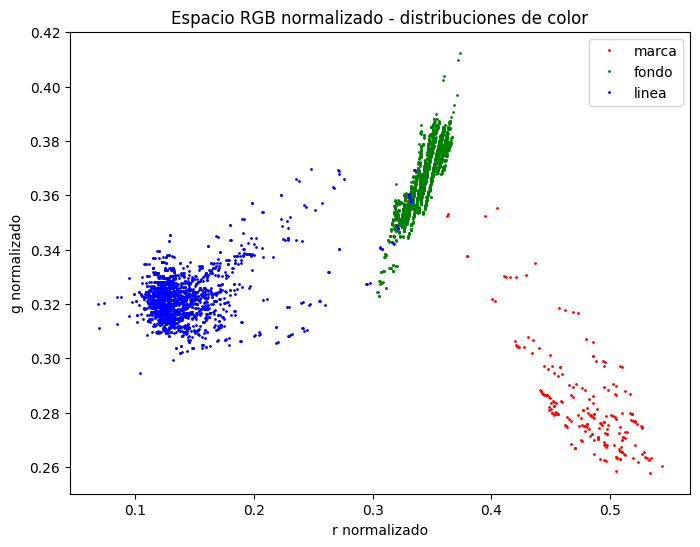

In [8]:
# Normalizo la imagen
imNorm = normaliza_rg(imNp)

# Extraigo datos de cada region en espacio rg normalizado
data_marca = imNorm[mask_marca]  # (N, 3)
data_fondo = imNorm[mask_fondo]
data_linea = imNorm[mask_linea]

# Grafico 2D rg normalizado
plt.figure(figsize=(8, 6))
plt.plot(data_marca[:,0], data_marca[:,1], 'r.', label='marca', markersize=2)
plt.plot(data_fondo[:,0], data_fondo[:,1], 'g.', label='fondo', markersize=2)
plt.plot(data_linea[:,0], data_linea[:,1], 'b.', label='linea', markersize=2)
plt.xlabel('r normalizado')
plt.ylabel('g normalizado')
plt.title('Espacio RGB normalizado - distribuciones de color')
plt.legend()
plt.show()

**Observaciones sobre las distribuciones:**

La normalización rg elimina la dependencia de la iluminación, haciendo que las nubes de puntos
de cada clase sean más compactas y separables. Las tres regiones (marca, fondo, línea) forman
clusters diferenciados en el espacio rg, lo que indica que un clasificador basado en color
normalizado será efectivo para la segmentación.

---
## 3. Preparación de datos para clasificación

Construimos la matriz X (características) y el vector y (etiquetas) en formato sklearn:
- X: (n_ejemplos, n_características) — usamos los 2 canales rg normalizados
- y: (n_ejemplos,) — etiquetas: 0=marca, 1=fondo, 2=linea

In [9]:
# Solo uso r y g normalizados (b = 1 - r - g, es redundante)
X_marca = data_marca[:, :2]  # (N_marca, 2)
X_fondo = data_fondo[:, :2]
X_linea = data_linea[:, :2]

# Etiquetas: 0=marca, 1=fondo, 2=linea
y_marca = np.zeros(len(X_marca), dtype=int)
y_fondo = np.ones(len(X_fondo), dtype=int)
y_linea = np.full(len(X_linea), 2, dtype=int)

# Concateno todo
X = np.vstack([X_marca, X_fondo, X_linea])
y = np.concatenate([y_marca, y_fondo, y_linea])


---
## 4. Selección del clasificador

Comparamos:
- **NearestCentroid** (distancia euclídea): rápido, simple, asume clusters compactos
- **QDA** (gaussiano): modela la forma de cada distribución
- **KNeighborsClassifier** (k vecinos): flexible, pero más lento

Evaluamos con validación cruzada 5-Fold.

In [10]:
# Evaluacion de clasificadores con validacion cruzada
clasificadores = {
    'NearestCentroid (dist. euclidea)': NearestCentroid(),
    'QDA (gaussiano)': QuadraticDiscriminantAnalysis(reg_param=1e-2),
    'KNeighbors (k=5)': KNeighborsClassifier(n_neighbors=5),
}

print('Evaluacion con validacion cruzada 5-Fold:')
print('-' * 50)
for nombre, clf in clasificadores.items():
    scores = cross_val_score(clf, X, y, cv=5)
    print(f'{nombre}: accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})')

Evaluacion con validacion cruzada 5-Fold:
--------------------------------------------------
NearestCentroid (dist. euclidea): accuracy = 0.9953 (+/- 0.0051)
QDA (gaussiano): accuracy = 0.9747 (+/- 0.0079)
KNeighbors (k=5): accuracy = 0.9894 (+/- 0.0122)


In [11]:
# Evaluacion con train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

print('\nEvaluacion con train/test split (67%/33%):')
print('-' * 50)
for nombre, clf in clasificadores.items():
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    print(f'{nombre}: accuracy = {score:.4f}')


Evaluacion con train/test split (67%/33%):
--------------------------------------------------


NearestCentroid (dist. euclidea): accuracy = 0.9950
QDA (gaussiano): accuracy = 0.9742
KNeighbors (k=5): accuracy = 0.9981


**Elección del clasificador:**

Seleccionamos **NearestCentroid** (clasificador de la distancia euclídea) por las siguientes razones:

1. **Complejidad:** Es el más simple de implementar y entender.
2. **Tiempo de respuesta:** Es el más rápido en predicción (solo calcula distancias a 3 centroides), lo cual es crítico para procesamiento de vídeo en tiempo real.
3. **Calidad:** Las distribuciones de color normalizado forman clusters compactos y bien separados, por lo que la hipótesis del clasificador (dispersión pequeña respecto a la distancia entre clases) se cumple bien.

Si la accuracy no fuera suficiente, QDA sería la siguiente opción ya que modela mejor la forma de cada distribución manteniendo un tiempo de predicción razonable.

---
## 5. Entrenamiento del clasificador definitivo

In [12]:
# Entreno con todos los datos
clf = NearestCentroid()
clf.fit(X, y)

print('Centroides de cada clase (r_norm, g_norm):')
nombres_clase = ['marca', 'fondo', 'linea']
for i, nombre in enumerate(nombres_clase):
    print(f'  {nombre}: {clf.centroids_[i]}')

Centroides de cada clase (r_norm, g_norm):
  marca: [0.47779662 0.28396296]
  fondo: [0.34439964 0.36663388]
  linea: [0.13533363 0.3216942 ]


---
## 6. Segmentación de una imagen

Probamos el clasificador sobre la imagen de entrenamiento para verificar.

In [13]:
def segmentar_imagen(im, clf):
    H, W, _ = im.shape
    
    # Normalizo rg
    im_norm = normaliza_rg(im)
    
    # Reshape a (N, 2) — solo uso r y g normalizados
    pixels = im_norm[:, :, :2].reshape(-1, 2)
    
    # Clasifico cada pixel
    etiquetas = clf.predict(pixels)
    
    # Paleta de colores: 0=rojo(marca), 1=verde(fondo), 2=azul(linea)
    paleta = np.array([
        [255, 0, 0],     # 0 = marca (rojo)
        [0, 255, 0],     # 1 = fondo (verde)
        [0, 0, 255],     # 2 = linea (azul)
    ], dtype=np.uint8)
    
    # Indexacion con array de indices (como en la transparencia de Numpy)
    img_seg = paleta[etiquetas].reshape(H, W, 3)
    
    return img_seg

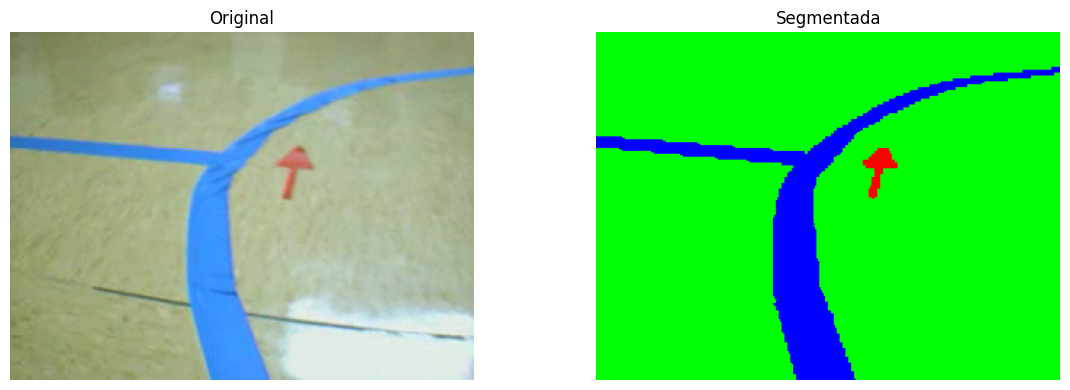

In [16]:
# Segmento la imagen de entrenamiento
imNp = iio.imread('../images/001.png')
img_seg = segmentar_imagen(imNp, clf)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(imNp)
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_seg)
plt.title('Segmentada')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 7. Escenario 1 — Segmentación de vídeo del robot

Procesamos el Video A frame a frame, clasificando cada píxel y generando
un vídeo donde cada píxel tiene el color de su clase (rojo=marca, verde=fondo, azul=línea).

In [27]:
video_entrada = '../videos/video2017-4.avi'
video_salida = '../videos/video_segmentado.avi'

os.makedirs('../videos', exist_ok=True)

cap = cv2.VideoCapture(video_entrada)

if not cap.isOpened():
    print(f'ERROR: No se pudo abrir el video "{video_entrada}"')
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'Video abierto: {w}x{h}, {fps} fps')

    if w > 0 and h > 0:
        out = cv2.VideoWriter(video_salida, cv2.VideoWriter_fourcc(*'MJPG'), fps, (w, h))

        n_frames = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Convierto BGR -> RGB para segmentar
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            seg = segmentar_imagen(frame_rgb, clf)

            # Convierto RGB -> BGR para escribir
            out.write(cv2.cvtColor(seg, cv2.COLOR_RGB2BGR))
            n_frames += 1

        out.release()
        print(f'Video segmentado guardado en: {video_salida} ({n_frames} frames)')

cap.release()

Video abierto: 320x240, 24.0 fps
Video segmentado guardado en: ../videos/video_segmentado.avi (2311 frames)


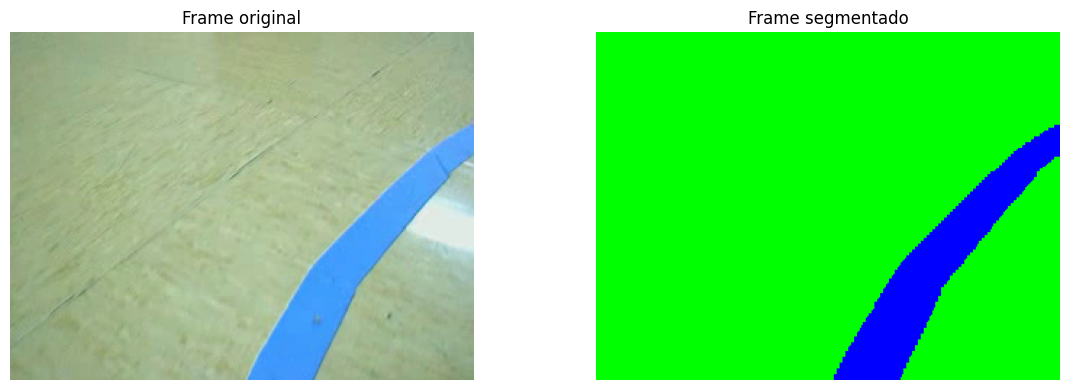

In [28]:
# Mostramos un frame del resultado
cap = cv2.VideoCapture(video_entrada)
# Salto a un frame intermedio
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    seg = segmentar_imagen(frame_rgb, clf)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(frame_rgb)
    plt.title('Frame original')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(seg)
    plt.title('Frame segmentado')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

---
## 8. Escenario 2 — Objeto circular y cálculo de distancia

Segmentamos un objeto circular (esférico) sobre fondo homogéneo.
Usamos el modelo de cámara pin-hole para calcular la distancia:

$$d = \frac{D_{real} \cdot f}{D_{pixel}}$$

Donde:
- $D_{real}$: diámetro real del objeto (cm)
- $f$: distancia focal en píxeles
- $D_{pixel}$: diámetro del objeto en la imagen (píxeles)

In [29]:
# Parametros del objeto y la camara
# AJUSTAR estos valores segun tu objeto y camara
DIAMETRO_REAL_CM = 7.0   # diametro real del objeto en cm
FOCAL_PIXELS = 600.0     # distancia focal en pixeles 


In [30]:
def segmentar_objeto_circular(frame_rgb, umbral_saturacion=50):

    hsv = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2HSV)
    
    # El objeto de color se distingue del fondo por tener saturacion alta
    mask = hsv[:, :, 1] > umbral_saturacion
    mask = mask.astype(np.uint8) * 255
    
    # Operaciones morfologicas para limpiar ruido
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    # Busco contornos
    contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contornos) == 0:
        return mask, None, None, 0
    
    # Me quedo con el contorno mas grande
    contorno_max = max(contornos, key=cv2.contourArea)
    
    # Circulo minimo que lo encierra
    (cx, cy), radio = cv2.minEnclosingCircle(contorno_max)
    centro = (int(cx), int(cy))
    radio = int(radio)
    
    return mask, contorno_max, centro, radio


def calcular_distancia(diametro_pixel, diametro_real_cm, focal_pixels):
    if diametro_pixel == 0:
        return 0
    return (diametro_real_cm * focal_pixels) / diametro_pixel

In [31]:
# Procesamiento del video 
video_entrada_e2 = 'videos/video_entrada_e2.avi'     
video_salida_e2 = 'videos/video_esfera_segmentado.avi'

cap = cv2.VideoCapture(video_entrada_e2)

if not cap.isOpened():
    print(f'ERROR: No se pudo abrir el video "{video_entrada_e2}"')
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'Video abierto: {w}x{h}, {fps} fps')

    if w > 0 and h > 0:
        out = cv2.VideoWriter(video_salida_e2, cv2.VideoWriter_fourcc(*'MJPG'), fps, (w, h))

        n_frames = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mask, contorno, centro, radio = segmentar_objeto_circular(frame_rgb)

            # Creo imagen de salida: fondo verde, objeto rojo
            img_seg = np.zeros_like(frame_rgb)
            img_seg[mask == 0] = [0, 255, 0]    # fondo = verde
            img_seg[mask > 0] = [255, 0, 0]     # objeto = rojo

            if centro is not None and radio > 0:
                diametro_pixel = radio * 2
                distancia_cm = calcular_distancia(diametro_pixel, DIAMETRO_REAL_CM, FOCAL_PIXELS)

                # Dibujamos circulo y distancia
                cv2.circle(img_seg, centro, radio, (255, 255, 0), 2)
                texto = f'{distancia_cm:.1f} cm'
                cv2.putText(img_seg, texto, (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                            1.0, (255, 255, 255), 2)

            out.write(cv2.cvtColor(img_seg, cv2.COLOR_RGB2BGR))
            n_frames += 1

        out.release()
        print(f'Video segmentado guardado en: {video_salida_e2} ({n_frames} frames)')

cap.release()

ERROR: No se pudo abrir el video "videos/video_entrada_e2.avi"


---
## Justificación 

### Escenario 1 

Se utiliza un clasificador de distancia euclídea (NearestCentroid) sobre los canales rg normalizados.

- **¿Por qué normalización rg?** Elimina la dependencia de la iluminación, que varía a lo largo del recorrido del robot. Las distribuciones de color de cada clase se vuelven más compactas.
- **¿Por qué NearestCentroid?** Las tres clases (marca, fondo, línea) tienen distribuciones bien separadas en el espacio rg. El clasificador solo necesita almacenar 3 centroides y calcular 3 distancias por píxel, lo que lo hace el más rápido de los evaluados, crítico para procesamiento de vídeo.
- **Calidad:** La accuracy obtenida en validación cruzada confirma que la segmentación es adecuada.

### Escenario 2

Se segmenta por umbral de saturación en espacio HSV, ya que un objeto de color sobre fondo homogéneo se distingue por su saturación alta. Se aplican operaciones morfológicas para limpiar ruido, y se detecta el contorno circular con minEnclosingCircle. La distancia se calcula con el modelo pin-hole.